In [1]:
inputs = [1,2,3,4]
weights = [2,3,4,5]
bias = 0.1

output = inputs[0]*weights[0] + inputs[1]*weights[1] + inputs[2]*weights[2] + inputs[3]*weights[3] + bias

print(f'the output of the percepton is: {output}')

the output of the percepton is: 40.1


In [2]:
p_output=0
out = 0.0
for weight, inp in zip(weights, inputs):
    out += weight*inp
    print(out)

p_output = out + bias
print(p_output)

2.0
8.0
20.0
40.0
40.1


In [3]:
new_weights = [
    [1, 2, 3],  # Row 1
    [4, 5, 6],  # Row 2
    [7, 8, 9],  # Row 3
    [10, 11, 12] # Row 4
]
inputs = [1,2,3,4]
bias = 0.0993

neuron_output = [0,0,0,0]

for inpt,weight_row in zip(inputs,new_weights):
    
    for neuron_index, weight in enumerate(weight_row):
        neuron_output[neuron_index] += weight*inpt

for i in range(len(neuron_output)):
    neuron_output[i] += bias

print(f'neuron_output : {neuron_output}')

    
        

neuron_output : [70.0993, 80.0993, 90.0993, 0.0993]


using numpy

In [4]:
import numpy as np
print(np.array([1,2,3]))

[1 2 3]


In [5]:
inputs = [1,2,3,4]
weights = [2,3,4,5]
bias = 0.1

output = np.dot(inputs,weights) + bias
print(output)

40.1


In [6]:
new_weights = np.array([
    [1, 2, 3],  # Row 1
    [4, 5, 6],  # Row 2
    [7, 8, 9],  # Row 3
    [10, 11, 12] # Row 4
])
inputs = [1,2,3,4]
bias = 0.0993

output = np.dot(new_weights.T, inputs) + bias
print("the outcome is", output)

the outcome is [70.0993 80.0993 90.0993]


In [7]:
import numpy as np

# 3 samples, each with 4 inputs -> Shape: (3, 4)
inputs = np.array([
    [1, 2, 3, 4],    # Sample 1
    [5, 6, 7, 8],    # Sample 2
    [9, 10, 11, 12]  # Sample 3
])

# 4 inputs, 5 output neurons -> Shape: (4, 5)
new_weights = np.array([
    [1,  2,  3,  13, 14],  
    [4,  5,  6,  15, 16],  
    [7,  8,  9,  17, 18],  
    [10, 11, 12, 19, 20]   
])

# A single bias value for each of the 5 neurons -> Shape: (5,)
bias = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
print(inputs.shape)
print(new_weights.shape)

output = np.dot(inputs, new_weights) + bias
print(output)

(3, 4)
(4, 5)
[[ 70.1  80.2  90.3 170.4 180.5]
 [158.1 184.2 210.3 426.4 452.5]
 [246.1 288.2 330.3 682.4 724.5]]


## multiple layers

In [8]:
inputs = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

#LAYER 1 WEIGHTS
weights_1 = np.array([
    [1,  2,  3,  4,  5],
    [6,  7,  8,  9,  10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20]
])
bias_1 = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

#LAYER 2
weights_2 = np.array([
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8],
    [9, 10]
])
bias_2 = np.array([0.99, 0.88])

layer1_outputs = np.dot(inputs,weights_1) + bias_1
print(layer1_outputs)
layer2_output = np.dot(layer1_outputs,weights_2) + bias_2
print(f"final :: {layer2_output}")

[[110.1 120.2 130.3 140.4 150.5]
 [246.1 272.2 298.3 324.4 350.5]
 [382.1 424.2 466.3 508.4 550.5]]
final :: [[ 3460.49  4111.88]
 [ 7980.49  9471.88]
 [12500.49 14831.88]]


# Dense Layer

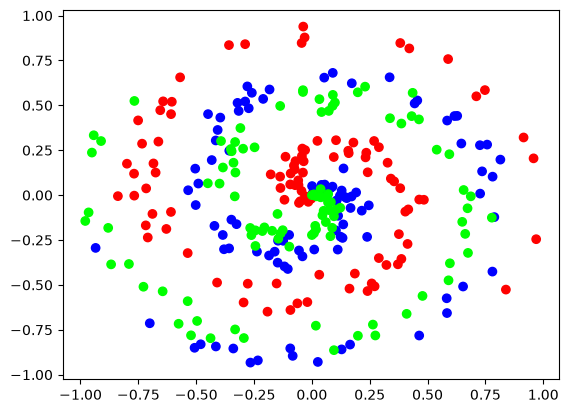

In [9]:
from nnfs.datasets import spiral_data
import nnfs

nnfs.init()
import matplotlib.pyplot as plt

X,y = spiral_data(samples=100, classes=3)
plt.scatter(X[:,0],X[:,1], c=y, cmap="brg")
plt.show()

In [10]:
class Layer_Dense:
    def __init__(self, n_inputs,n_neurons):
        self.weights = 0.01*np.random.randn(n_inputs,n_neurons)
        self.biases = np.zeros((1,n_neurons))

    def foward(self,inputs):
        self.outputs = np.dot(inputs, self.weights) + self.biases

dense1 = Layer_Dense(2,5)
dense1.foward(X)
print(dense1.outputs[:3])
dense2 = Layer_Dense(len(dense1.outputs),5)
print(dense2.outputs[:3])

[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
   0.0000000e+00]
 [-8.3581581e-05 -7.9040430e-05 -1.3345221e-04  4.6550449e-05
   4.5684628e-06]
 [-2.3999445e-04  5.9346880e-06 -2.2480826e-04  2.0357311e-05
   6.1002436e-05]]


AttributeError: 'Layer_Dense' object has no attribute 'outputs'

In [ ]:
class Activation_ReLU:
    def foward(self, inputs):
        self.outputs = np.maximum(0,inputs)

In [ ]:
class Activation_Sigmoid:
    def foward(self,inputs):
        clip_inputs = np.clip(inputs, -500, 500)
        self.outputs = 1/(1+np.exp(-clip_inputs))

In [ ]:
class Activation_Softmax:
    def foward(self,inputs):
        probs = np.exp(inputs-np.max(inputs, axis=1,keepdims=True))
        self.outputs = probs / np.sum(probs, axis=1,keepdims=True)
        

In [ ]:
mock_layer_outputs = np.array([
    [1.0,  2.0, -3.0],
    [4.5, -1.2,  0.0]
])
relu = Activation_ReLU()
sigmoid = Activation_Sigmoid()
softmax=Activation_Softmax()

relu.foward(mock_layer_outputs)
sigmoid.foward(mock_layer_outputs)
softmax.foward(mock_layer_outputs)

print("-- Original Raw Outputs--\n", mock_layer_outputs)
print("\n --- relu----\n",relu.outputs)
print("\n---softmax---\n",softmax.outputs)
print("\n ---softmax--\n",softmax.outputs)

print("\n -- softmax row sums ---\n",np.sum(softmax.outputs, axis=1))

In [ ]:
class Layer_Dense_with_activation:
    def __init__(self,n_inputs,n_neurons):
        self.weights = 0.001 * np.random.randn(n_inputs,n_neurons)
        self.biases = np.zeros((1,n_neurons))

    
    def foward(self, inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

class Activation_ReLU:
    def foward(self,inputs):
        self.output = np.maximum(0,inputs)

class Activation_Sigmoid:
    def foward(self,inputs):
        clipped_out = np.clip(inputs,-200,200)
        self.output = 1/ (1+np.exp(-clipped_out))

class Activation_Softmax:
    def foward(self,inputs):
        checked_inpt = inputs-np.max(inputs, axis=1, keepdims=True)
        self.output = np.exp(checked_inpt)/ np.sum(np.exp(checked_inpt), axis=1,keepdims=True)


dense1 = Layer_Dense_with_activation(2,64)
activation1=Activation_ReLU()
dense1.foward(X)
activation1.foward(dense1.output)

dense2 = Layer_Dense_with_activation(64,3)
activation2=Activation_Softmax()
dense2.foward(activation1.output)
activation2.foward(dense2.output)

print(activation2.output[:3])

<div>
<h1 style="color: red"> Intoduction to categorical cross entropy. </h1>
</div>

In [23]:
class Loss_CategoricalCrossEntropy:
    def forward(self,y_pred,y_true):
        samples = len(y_pred)

        y_pred_clipped = np.clip(y_pred,1e-7, 1-1e-7)

        if len(y_true.shape) == 1:
            c_confidence = y_pred_clipped[range(samples), y_true]

        elif len(y_true.shape) == 2:
            c_confidence = np.sum(y_pred_clipped * y_true, axis=1)

        negative_log_likelihoods = -np.log(c_confidence)
        return np.mean(negative_log_likelihoods)

In [25]:
softmax_outputs = np.array([
    [0.7, 0.1, 0.2],   # Sample 1: Very confident in Class 0
    [0.1, 0.5, 0.4],   # Sample 2: Fairly confident in Class 1
    [0.02, 0.08, 0.9]  # Sample 3: Extremely confident in Class 2
])

# The actual ground truth classes for those 3 samples
class_targets = np.array([0, 1, 2]) 
# Note: Sample 3's true class is 1, but our network predicted class 2 (index 2)!

# Instantiate and calculate loss
loss_function = Loss_CategoricalCrossEntropy()
average_loss = loss_function.forward(softmax_outputs, class_targets)

print("Average Batch Loss: ",average_loss)

Average Batch Loss:  0.38506088005216804
